# Pattern Recognition & Biometrics Classification

## Part I. Linear Classification: Naive Bayes Classifier

In [ ]:
from pathlib import Path
import os
import pandas as pd

NOTEBOOK_DIR = Path(r"E:\code\code")
os.chdir(NOTEBOOK_DIR)

PenguinData = pd.read_csv("penguins_classification.csv")
print(PenguinData.head())

   Culmen Length (mm)  Culmen Depth (mm) Species
0                39.1               18.7  Adelie
1                39.5               17.4  Adelie
2                40.3               18.0  Adelie
3                36.7               19.3  Adelie
4                39.3               20.6  Adelie


number of examples

In [8]:
PenguinData["Species"].value_counts()

Species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

Computing the prior probability for each class

In [9]:
counts = PenguinData['Species'].value_counts()
priors = counts / len(PenguinData)
print(priors)

Species
Adelie       0.441520
Gentoo       0.359649
Chinstrap    0.198830
Name: count, dtype: float64


histrograms of the input variables

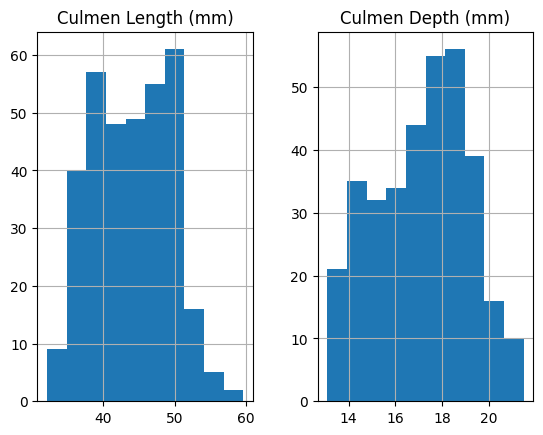

In [10]:

_ = PenguinData.hist()

 variable distributions per class

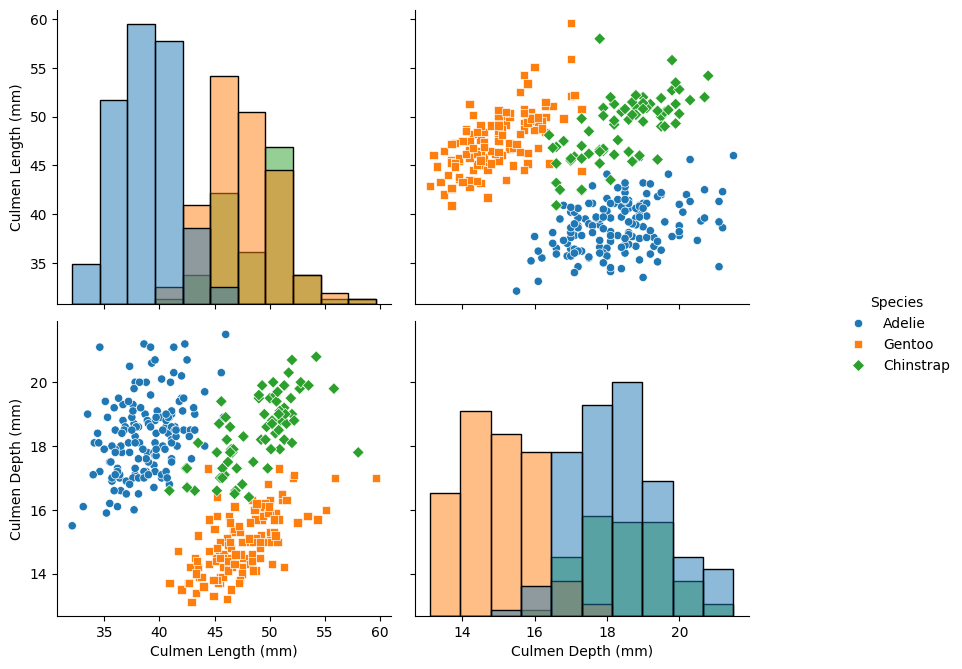

In [ ]:
import seaborn as sns
pairplot_figure = sns.pairplot(data = PenguinData, hue = "Species", diag_kind="hist", markers = ["o", "s", "D"])
pairplot_figure.fig.set_size_inches(10, 7)

Redo the previous graph, but this time with the histrograms by kernel estimations of the density probability function per class. 

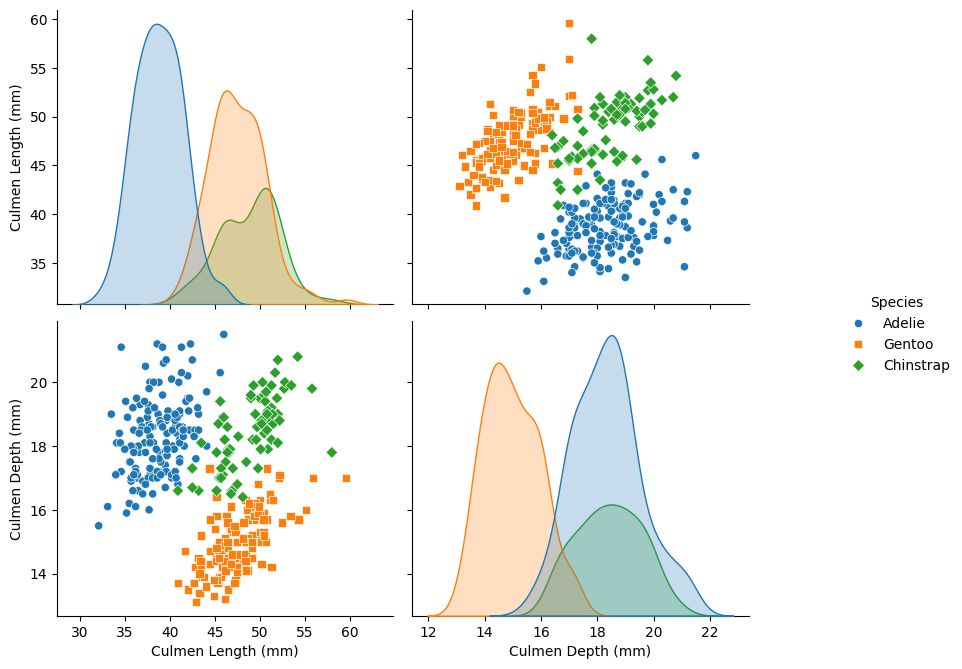

In [ ]:
import seaborn as sns
pairplot_figure2 = sns.pairplot(data = PenguinData, hue = "Species", diag_kind="kde", markers = ["o", "s", "D"])
pairplot_figure2.fig.set_size_inches(10, 7)


No single variable is sufficient on its own. Culmen length separates Gentoo from the rest fairly well, but Adelie and Chinstrap overlap in both features. Using only one variable would leave a significant error rate.

if culmen_depth < 16.5 mm  →  Gentoo
elif culmen_length > 45 mm  →  Chinstrap
else  →  Adelie


 a naive Bayes classifier, train it with *data_train* and *target_train* defined below, for predicting the penguin species 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

data_train, data_test, target_train, target_test = train_test_split(
    PenguinData[['Culmen Length (mm)', 'Culmen Depth (mm)']],
    PenguinData['Species'],
    test_size=0.3, shuffle=True, random_state=42
)

nb_clf = GaussianNB()
nb_clf.fit(data_train, target_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


the classifier's error rate.

In [ ]:
pred_nb = nb_clf.predict(data_test)
error_rate = (pred_nb != target_test.values).mean()
print(f'Error rate: {error_rate:.4f}')

Error rate: 0.0583


 Minimal Bayes Error Risk

In [ ]:
# P(error | x) = 1 - max_c P(c | x), averaged over test samples
proba = nb_clf.predict_proba(data_test)
bayes_risk = (1 - proba.max(axis=1)).mean()
print(f'Minimal error risk (Bayes): {bayes_risk:.4f}')
print(f'Empirical error rate:       {error_rate:.4f}')

Minimal error risk (Bayes): 0.0494
Empirical error rate:       0.0583


## Part II. Nonlinear classification with Neural Networks

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

input_preprocessor = StandardScaler()
target_preprocessor = OneHotEncoder(sparse_output=False)

data = input_preprocessor.fit_transform(PenguinData[['Culmen Length (mm)', 'Culmen Depth (mm)']])
target = target_preprocessor.fit_transform(PenguinData[['Species']])

normdf = pandas.DataFrame(
    np.concatenate((PenguinData[['Culmen Length (mm)', 'Culmen Depth (mm)']].values, data), axis=1),
    columns=['Var1', 'Var2', 'Var1 norm', 'Var2 norm']
)
print('Normalized input data')
print(normdf[:10])
print('Target output')
print(pandas.DataFrame(target, columns=['Adelie', 'Chinstrap', 'Gentoo']))

Normalized input data
   Var1  Var2  Var1 norm  Var2 norm
0  39.1  18.7  -0.884499   0.785449
1  39.5  17.4  -0.811126   0.126188
2  40.3  18.0  -0.664380   0.430462
3  36.7  19.3  -1.324737   1.089724
4  39.3  20.6  -0.847812   1.748985
5  38.9  17.8  -0.921185   0.329038
6  39.2  19.6  -0.866155   1.241861
7  34.1  18.1  -1.801661   0.481175
8  42.0  20.2  -0.352544   1.546135
9  37.8  17.1  -1.122961  -0.025949
Target output
     Adelie  Chinstrap  Gentoo
0       1.0        0.0     0.0
1       1.0        0.0     0.0
2       1.0        0.0     0.0
3       1.0        0.0     0.0
4       1.0        0.0     0.0
..      ...        ...     ...
337     0.0        1.0     0.0
338     0.0        1.0     0.0
339     0.0        1.0     0.0
340     0.0        1.0     0.0
341     0.0        1.0     0.0

[342 rows x 3 columns]


 an MLP with $N_{hl} = 1$ hidden layer containing $m=2$ neurons. 

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn import set_config
m = 2
mlpmodel = MLPClassifier(hidden_layer_sizes=(m, ), activation="logistic", solver="lbfgs", max_iter=2000, random_state=42)
set_config(display='diagram')
mlpmodel


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(2,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


 train the MLP and test its generalization capacity


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.3, shuffle=True, random_state=42
)

# training
mlpmodel.fit(X_train, y_train)

pred_tr   = mlpmodel.predict(X_train)
pred_test = mlpmodel.predict(X_test)

# argmax decoding is robust when predictions aren't perfectly one-hot
cats = target_preprocessor.categories_[0]
pred_tr_label   = cats[pred_tr.argmax(axis=1)].reshape(-1, 1)
train_label     = cats[y_train.argmax(axis=1)].reshape(-1, 1)
pred_test_label = cats[pred_test.argmax(axis=1)].reshape(-1, 1)
test_label      = cats[y_test.argmax(axis=1)].reshape(-1, 1)

table_test = pandas.DataFrame(
    np.concatenate((pred_test_label, test_label), axis=1),
    columns=['Predicted label', 'True label']
)
table_test[65:75]

,Predicted label,True label
65,Chinstrap,Adelie
66,Adelie,Adelie
67,Adelie,Adelie
68,Adelie,Adelie
69,Adelie,Adelie
70,Adelie,Adelie
71,Adelie,Adelie
72,Chinstrap,Chinstrap
73,Adelie,Chinstrap
74,Chinstrap,Chinstrap


Computing the model performance:

In [ ]:
#Performance training
acc_tr = (pred_tr_label == train_label).mean()

#Performance test
acc_test = (pred_test_label == test_label).mean()

print(f"The training accuracy is {acc_tr:.4f}")
print(f"The testing accuracy is {acc_test:.4f}")

The training accuracy is 0.9707
The testing accuracy is 0.9806


confusion matrix (for the test set)

              precision    recall  f1-score   support

      Adelie       0.98      0.98      0.98        50
   Chinstrap       0.95      0.95      0.95        19
      Gentoo       1.00      1.00      1.00        34

    accuracy                           0.98       103
   macro avg       0.98      0.98      0.98       103
weighted avg       0.98      0.98      0.98       103



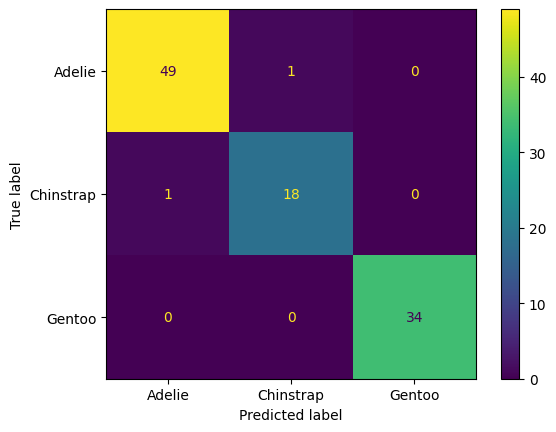

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(test_label, pred_test_label)
disp = ConfusionMatrixDisplay(cm, display_labels=target_preprocessor.categories_[0])
disp.plot()

print(classification_report(test_label, pred_test_label,
                             target_names=target_preprocessor.categories_[0]))

cross-validation to properly estimate the generalization of the model

In [ ]:
import numpy
from sklearn.model_selection import cross_validate, KFold

data_shuffle1, data_shuffle2, target_shuffle1, target_shuffle2 = train_test_split(
    data, target, train_size=341, shuffle=True, random_state=0
)
data_shuffle   = numpy.concatenate((data_shuffle1, data_shuffle2), axis=0)
target_shuffle = numpy.concatenate((target_shuffle1, target_shuffle2), axis=0)

cv_folds = KFold(n_splits=10, shuffle=True, random_state=42)

mlp_cv = MLPClassifier(hidden_layer_sizes=(2,), activation='logistic',
                       solver='lbfgs', max_iter=2000, random_state=42)
cv_res = cross_validate(mlp_cv, data_shuffle, target_shuffle, cv=cv_folds,
                        return_train_score=True)

print(f"Train: {cv_res['train_score'].mean():.4f} ± {cv_res['train_score'].std():.4f}")
print(f"Test:  {cv_res['test_score'].mean():.4f} ± {cv_res['test_score'].std():.4f}")


Train: 0.9688 ± 0.0044
Test:  0.9592 ± 0.0324


Finding The optimal number of hidden neurons $m_{opt}$ empirically, by varying the value of $m$ and evaluating the performance. 

In [ ]:
from sklearn.model_selection import cross_validate, KFold

results = {}
cv_folds = KFold(n_splits=10, shuffle=True, random_state=42)

for m_val in range(2, 11):
    model = MLPClassifier(hidden_layer_sizes=(m_val,), activation='logistic',
                          solver='lbfgs', max_iter=2000, random_state=42)
    cv = cross_validate(model, data_shuffle, target_shuffle, cv=cv_folds,
                        return_train_score=True)
    results[m_val] = {
        'train': cv['train_score'].mean(),
        'test': cv['test_score'].mean(),
    }
    print(f'm={m_val}  train={results[m_val]["train"]:.4f}  test={results[m_val]["test"]:.4f}')

m_opt = max(results, key=lambda m: results[m]['test'])
print(f'\nm_opt = {m_opt}, test accuracy = {results[m_opt]["test"]:.4f}')


m=2  train=0.9688  test=0.9592


m=3  train=0.9695  test=0.9679


m=4  train=0.9786  test=0.9564


m=5  train=0.9857  test=0.9649


m=6  train=0.9841  test=0.9418


m=7  train=0.9857  test=0.9535


m=8  train=0.9841  test=0.9564


m=9  train=0.9912  test=0.9591


m=10  train=0.9958  test=0.9533

m_opt = 3, test accuracy = 0.9679


$m=3$ achieves the highest mean test accuracy. For $m > 3$, training accuracy increases while test accuracy decreases, which indicates overfitting.


measuring the impact of the train set size on the model performance. 

n= 10  train=1.0000  test=1.0000


n= 50  train=1.0000  test=0.9800


n=100  train=1.0000  test=0.9800


n=150  train=1.0000  test=0.9733


n=200  train=0.9983  test=0.9600


n=250  train=0.9769  test=0.9480


n=300  train=0.9722  test=0.9567


n=342  train=0.9695  test=0.9679


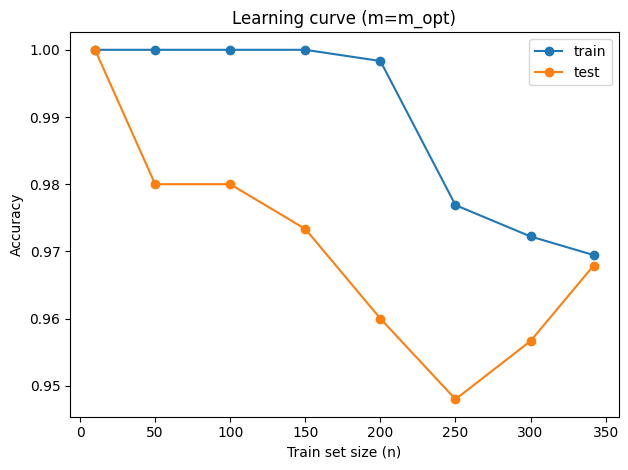

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, KFold

n_values  = [10, 50, 100, 150, 200, 250, 300, 342]
train_acc = []
test_acc  = []

for n in n_values:
    model = MLPClassifier(hidden_layer_sizes=(m_opt,), activation='logistic',
                          solver='lbfgs', max_iter=2000, random_state=42)
    k = min(10, n)
    cv_split = KFold(n_splits=k, shuffle=True, random_state=42) if k > 1 else 2
    cv = cross_validate(model, data_shuffle[:n], target_shuffle[:n],
                        cv=cv_split, return_train_score=True)
    train_acc.append(cv['train_score'].mean())
    test_acc.append(cv['test_score'].mean())
    print(f'n={n:3d}  train={cv["train_score"].mean():.4f}  test={cv["test_score"].mean():.4f}')

plt.figure()
plt.plot(n_values, train_acc, marker='o', label='train')
plt.plot(n_values, test_acc,  marker='o', label='test')
plt.xlabel('Train set size (n)')
plt.ylabel('Accuracy')
plt.title('Learning curve (m=m_opt)')
plt.legend()
plt.tight_layout()
plt.show()


## PART III. Prediction of cardiovascular risk 

=== Naive Bayes - Cardio ===
              precision    recall  f1-score   support

   no cardio       0.56      0.87      0.68     10461
      cardio       0.71      0.32      0.44     10539

    accuracy                           0.59     21000
   macro avg       0.64      0.60      0.56     21000
weighted avg       0.64      0.59      0.56     21000



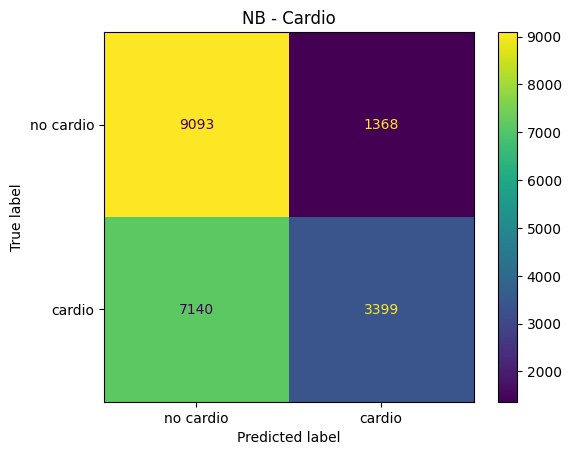

Weight threshold(s): [25.61122244 77.7755511 ]


In [ ]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

cardio = pandas.read_csv('cardio_train.csv', sep=';')
cardio = cardio.drop(columns='id')

features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active']
X_cardio = cardio[features].values
y_cardio = cardio['cardio'].values

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cardio, y_cardio, test_size=0.3, random_state=42
)

nb_cardio = GaussianNB()
nb_cardio.fit(Xc_train, yc_train)
yc_pred = nb_cardio.predict(Xc_test)

print('=== Naive Bayes - Cardio ===')
print(classification_report(yc_test, yc_pred, target_names=['no cardio', 'cardio']))
ConfusionMatrixDisplay(confusion_matrix(yc_test, yc_pred),
                       display_labels=['no cardio', 'cardio']).plot()
plt.title('NB - Cardio')
plt.show()

# III.2 · decision threshold for 'weight'
weight_idx = features.index('weight')
mu0, mu1   = nb_cardio.theta_[0, weight_idx], nb_cardio.theta_[1, weight_idx]
var0, var1 = nb_cardio.var_[0, weight_idx],   nb_cardio.var_[1, weight_idx]

# solve analytically where log P(c=0|x) = log P(c=1|x) for a single feature
w_range = numpy.linspace(X_cardio[:, weight_idx].min(),
                          X_cardio[:, weight_idx].max(), 500)
log_p0 = -0.5 * ((w_range - mu0)**2) / var0 - 0.5 * np.log(var0)
log_p1 = -0.5 * ((w_range - mu1)**2) / var1 - 0.5 * np.log(var1)
diff   = log_p0 - log_p1
# threshold is where diff crosses zero
sign_changes = numpy.where(numpy.diff(numpy.sign(diff)))[0]
thresholds = w_range[sign_changes]
print(f'Weight threshold(s): {thresholds}')

 Train and evaluate a Multilayer Perceptron for the same dataset
 Compare the performances of both models

=== MLP - Cardio ===
              precision    recall  f1-score   support

   no cardio       0.70      0.81      0.75     10461
      cardio       0.77      0.65      0.71     10539

    accuracy                           0.73     21000
   macro avg       0.74      0.73      0.73     21000
weighted avg       0.74      0.73      0.73     21000



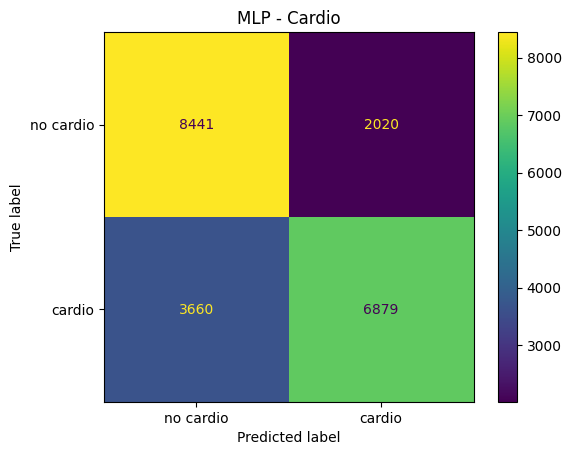


--- Comparison ---
NB  accuracy : 0.5949
MLP accuracy : 0.7295
NB  F1 (macro): 0.5627
MLP F1 (macro): 0.7280


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
Xc_train_n = scaler.fit_transform(Xc_train)
Xc_test_n  = scaler.transform(Xc_test)

mlp_cardio = MLPClassifier(hidden_layer_sizes=(m_opt,), activation='logistic',
                            solver='lbfgs', max_iter=2000, random_state=42)
mlp_cardio.fit(Xc_train_n, yc_train)
yc_pred_mlp = mlp_cardio.predict(Xc_test_n)

print('=== MLP - Cardio ===')
print(classification_report(yc_test, yc_pred_mlp, target_names=['no cardio', 'cardio']))
ConfusionMatrixDisplay(confusion_matrix(yc_test, yc_pred_mlp),
                       display_labels=['no cardio', 'cardio']).plot()
plt.title('MLP - Cardio')
plt.show()

# side-by-side comparison
from sklearn.metrics import f1_score
print('\n--- Comparison ---')
print(f'NB  accuracy : {(yc_pred     == yc_test).mean():.4f}')
print(f'MLP accuracy : {(yc_pred_mlp == yc_test).mean():.4f}')
print(f'NB  F1 (macro): {f1_score(yc_test, yc_pred,     average="macro"):.4f}')
print(f'MLP F1 (macro): {f1_score(yc_test, yc_pred_mlp, average="macro"):.4f}')
